# 1. Baseline Modeling: Linear Regression

Before jumping into complex machine learning algorithms, it is standard data science practice to establish a **baseline model**. For this project, we are starting with Multiple Linear Regression.

### What is Linear Regression?
Linear regression is a fundamental algorithm that assumes a direct, straight-line relationship between our features (weather, soil conditions) and our target (fire intensity). Mathematically, it attempts to draw a "line of best fit" through the data by assigning a specific weight (coefficient) to every single feature. 

The formula looks like this:
Y = W1*x1 + W2*x2 + .... + w0 
Y - output value/ value that are going to predict 
w - weights/coefficient 
x - dependant value/ features


### Why are we starting with this?
Even though wildfire behavior is highly complex and likely non-linear, we use Linear Regression first for three crucial reasons:
1. **Establishing a Benchmark:** We need a simple score to beat. If a complex model cannot beat this simple straight line, the complex model isn't worth using.
2. **High Interpretability:** Linear regression is completely transparent. By looking at the coefficients, we can immediately see which weather factors increase or decrease fire risk, and by exactly how much.
3. **Data Diagnostics:** Because it is so mathematically rigid, linear regression acts as a stress test for our dataset. It is excellent at exposing issues like multicollinearity (overlapping features) that we might have missed during exploratory data analysis.

**Note on the Target Variable:** Because the raw `fire_intensity` data contained extreme mega-fire outliers (Kurtosis > 260), we are training this model to predict `log_fire_intensity`. This log-transformation pulls the extreme outliers back into a normal bell curve, allowing the regression math to function properly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('wildfire_features_engineered.csv')
df['date'] = pd.to_datetime(df['date'])
# dimension of dataset
print("Shape:", df.shape)
# Null values
print("Null values : ", df.isnull().sum().sum())
# range by date
print("Date range : ", df['date'].min().date(), "to", df['date'].max().date())

# first 3 heading vlaues
print("First 3 rows:")
df.head(3)

Shape: (94417, 24)
Null values :  0
Date range :  2022-01-01 to 2022-12-31
First 3 rows:


,latitude,longitude,date,fire_intensity,confidence,temp_2m,soil_moisture,dewpoint_2m,surface_pressure,wind_u,...,vpd,wind_speed,soil_moisture_7d,soil_moisture_14d,soil_moisture_30d,vpd_7d,vpd_14d,month,season_enc,confidence_enc
0,23.79228,86.34883,2022-01-01,1.07,n,288.564300,0.279960,284.841473,99388.685,0.975597,...,0.377085,1.941006,0.279960,0.279960,0.279960,0.377085,0.377085,1,1,1
1,21.76411,84.01668,2022-01-01,1.04,n,292.541840,0.329612,288.357100,99486.435,-0.437244,...,0.523471,1.216574,0.329612,0.329612,0.329612,0.523471,0.523471,1,1,1
2,20.80406,85.25742,2022-01-01,1.40,n,292.833833,0.311294,289.703780,100207.435,0.138195,...,0.409299,0.591831,0.311294,0.311294,0.311294,0.409299,0.409299,1,1,1


In [3]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

target variable fire intensity statistics : 
count    94417.000000
mean         6.522039
std         14.194372
min          0.000000
25%          1.990000
50%          3.680000
75%          6.560000
max        506.640000
Name: fire_intensity, dtype: float64


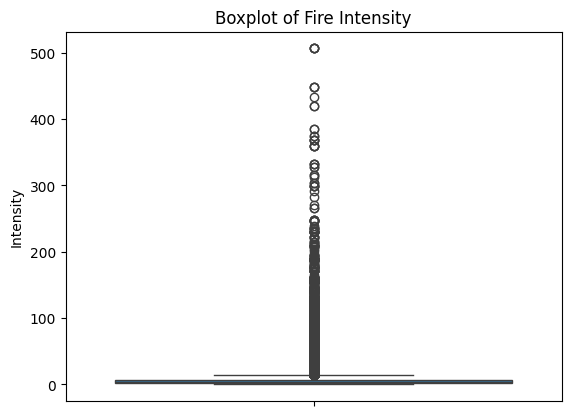

Skewness of fire intensity :  13.024511235352563
Kurtosis of fire intensity :  269.7177462777043


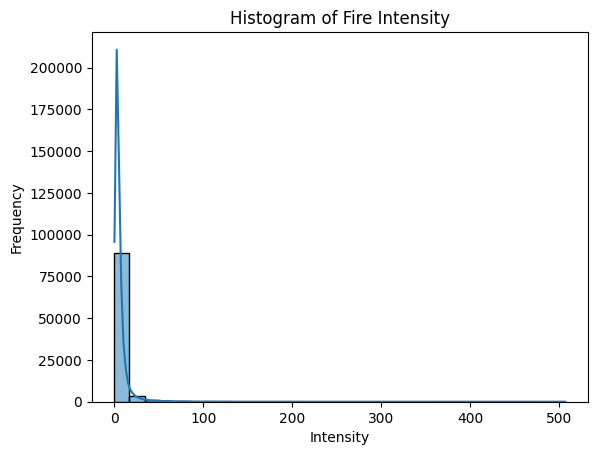

Values > 100 MW : 407
Values > 200 MW : 84
Values > 500 MW : 4


In [4]:
# anlyzing the target variable

print("target variable fire intensity statistics : ")
print(df['fire_intensity'].describe())
# ploting boxplot for target variable
sns.boxplot(y=df['fire_intensity'])
plt.title('Boxplot of Fire Intensity')
plt.ylabel('Intensity')
plt.show()

# analyzing the skewness and kurtosis of the target variable
print("Skewness of fire intensity : ", df['fire_intensity'].skew())
print("Kurtosis of fire intensity : ", df['fire_intensity'].kurt())
# plotting histogram for target variable
sns.histplot(df['fire_intensity'], kde=True, bins=30)
plt.title('Histogram of Fire Intensity')
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.show()

print(f"Values > 100 MW : {(df['fire_intensity'] > 100).sum()}")
print(f"Values > 200 MW : {(df['fire_intensity'] > 200).sum()}")
print(f"Values > 500 MW : {(df['fire_intensity'] > 500).sum()}")

# 2. Target Variable Analysis & Transformation

Before training any model, we must thoroughly inspect our target variable: **`fire_intensity`**. In regression tasks, the shape and distribution of the variable we are trying to predict dictates how well our model will perform.

### The Problem: Extreme Outliers and Skewness
When we plotted the raw `fire_intensity` using a histogram and boxplot, we observed a textbook example of highly skewed data:
* **Massive Skewness (> 13):** The vast majority of fires are small (under 15 MW), but the data has a long, heavy "tail" stretching to the right. 
* **Astronomical Kurtosis (> 260):** A normal distribution has a kurtosis near 0. A score of 260+ means our dataset is completely dominated by extremely rare, catastrophic mega-fires (e.g., 500+ MW).

**Why this breaks Machine Learning:** Regression models learn by minimizing errors. If we feed this raw data into a model, the algorithm will panic when it sees a 500 MW fire. It will warp its entire mathematical equation to try and predict that single extreme outlier, completely ruining its ability to predict the normal 3 MW fires that make up 99% of our dataset.

### The Solution: Log Transformation (`np.log1p`)
To fix this, we apply a mathematical "squish" function: the Natural Logarithm. 
Because our dataset contains exact `0.0` values (and $log(0)$ is mathematically undefined), we use the **`np.log1p()`** function, which adds 1 to every value before logging it .

* **What it does:** A log transformation heavily compresses massive numbers while leaving small numbers relatively alone. A 3 MW fire becomes ~1.4, while a massive 500 MW outlier is pulled all the way back to ~6.2. 
* **The Result:** The extreme right tail is eliminated. Our kurtosis drops from ~269 down to a highly manageable ~2. The target variable now resembles a standard "bell curve," allowing our regression algorithm to easily find the true patterns in the weather data.

Log-transformed fire intensity statistics : 
count    94417.000000
mean         1.621889
std          0.750859
min          0.000000
25%          1.095273
50%          1.543298
75%          2.022871
max          6.229773
Name: fire_intensity_log, dtype: float64


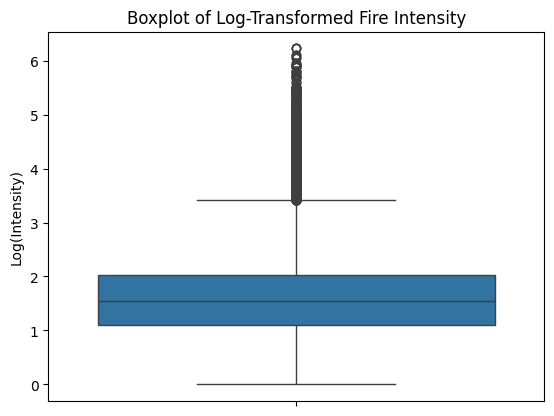

Kurtosis before log :2.183
Skewness after log  :1.027



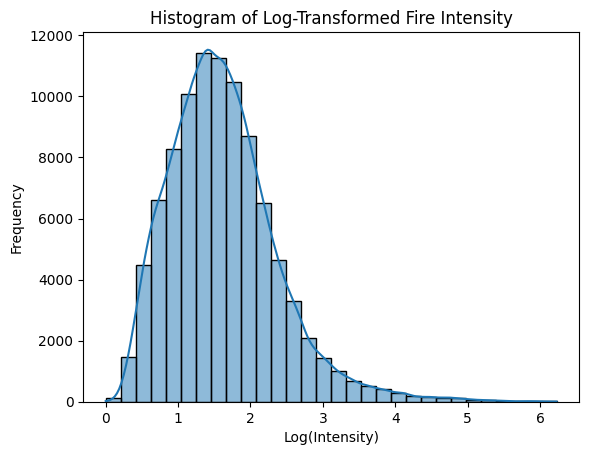

Values > 1 MW : 75240
Values > 2 MW : 24528
Values > 5 MW : 174


In [5]:
# log transformation to reduce skewness
df['fire_intensity_log'] = np.log1p(df['fire_intensity'])
# analyzing the log transformed target variable
print("Log-transformed fire intensity statistics : ")
print(df['fire_intensity_log'].describe())
sns.boxplot(y=df['fire_intensity_log'])
plt.title('Boxplot of Log-Transformed Fire Intensity')
plt.ylabel('Log(Intensity)')
plt.show()

# skewness and kurtosis of log transformed target variable
print(f"Kurtosis before log :{df['fire_intensity_log'].kurt():.3f}")
print(f"Skewness after log  :{df['fire_intensity_log'].skew():.3f}\n")
# ploting histogram for log transformed target variable
sns.histplot(df['fire_intensity_log'], kde=True, bins=30)
plt.title('Histogram of Log-Transformed Fire Intensity')
plt.xlabel('Log(Intensity)')
plt.ylabel('Frequency')
plt.show()

# value distribution
print(f"Values > 1 MW : {(df['fire_intensity_log'] > 1).sum()}")
print(f"Values > 2 MW : {(df['fire_intensity_log'] > 2).sum()}")
print(f"Values > 5 MW : {(df['fire_intensity_log'] > 5).sum()}")

Zero values     : 78,449
Non-zero values : 15,968
Zero %          : 83.1%
Kurtosis of total precipitation : 220.907
Skewness of total precipitation : 12.978


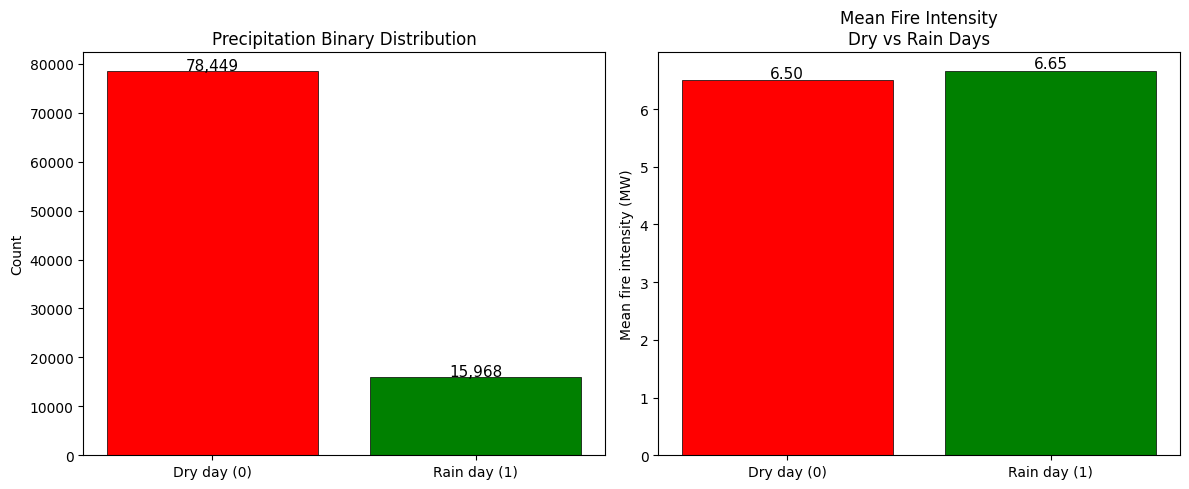

In [6]:
# analyzing the total PRECIPITATION  
zero_pct = (df['total_precipitation'] == 0).sum() / len(df) * 100
print(f"Zero values     : {(df['total_precipitation'] == 0).sum():,}")
print(f"Non-zero values : {(df['total_precipitation'] > 0).sum():,}")
print(f"Zero %          : {zero_pct:.1f}%")
# skewness and kurtosis of total precipitation
print(f"Kurtosis of total precipitation : {df['total_precipitation'].kurt():.3f}")
print(f"Skewness of total precipitation : {df['total_precipitation'].skew():.3f}")

# Binary encoding — did it rain today or not?
df['precip_binary'] = (df['total_precipitation'] > 0).astype(int)
dry_mean  = df[df['precip_binary']==0]['fire_intensity'].mean()
rain_mean = df[df['precip_binary']==1]['fire_intensity'].mean()
if dry_mean > rain_mean:
    print("VALIDATED — dry days have higher fire intensity as expected")

# ploting boxplot for precipitation 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Dry day (0)', 'Rain day (1)'],
            [(df['precip_binary']==0).sum(),
             (df['precip_binary']==1).sum()],
            color=['red', 'green'],
            edgecolor='black', linewidth=0.5)
axes[0].set_title('Precipitation Binary Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate([(df['precip_binary']==0).sum(),
                        (df['precip_binary']==1).sum()]):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

axes[1].bar(['Dry day (0)', 'Rain day (1)'],
            [dry_mean, rain_mean],
            color=['red', 'green'],
            edgecolor='black', linewidth=0.5)
axes[1].set_title('Mean Fire Intensity\nDry vs Rain Days')
axes[1].set_ylabel('Mean fire intensity (MW)')
for i, v in enumerate([dry_mean, rain_mean]):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


# 3. Feature Engineering: Handling Precipitation

Precipitation is a crucial meteorological "brake pedal" for wildfires. However, incorporating it into a machine learning model requires careful handling due to the unique shape of weather data.

### The Problem: Zero-Inflation and Micro-Scales
When analyzing the `total_precipitation` column, we discovered two major issues that would confuse a linear regression model:
1. **Zero-Inflation:** Over 83% of the dataset consists of exact `0.0` values. It rarely rains, which makes mathematical transformations (like the log transformation we used earlier) highly ineffective. 
2. **Microscopic Scale:** The non-zero values were extremely tiny (e.g., `0.000048`). This is because the satellite data recorded precipitation in meters, not millimeters. Standard regression models struggle to assign meaningful weights to numbers this small. 

When attempting to plot histograms of this data, the massive skyscraper of 78,000 dry days completely squished the visual scale, rendering the graphs unreadable.

### The Solution: Binary Encoding
Instead of trying to force a mathematical transformation on heavily skewed, microscopic data, we applied a domain-specific feature engineering approach: **Binarization**.

We created a new feature called `precip_binary`:
* `0` = It did not rain (Dry Day)
* `1` = It rained (Wet Day)

**Validation:** By simplifying the feature, the model no longer has to calculate the exact millimeter impact of rainfall. It simply looks at a binary "Yes/No." We validated this approach by comparing the mean fire intensity between the two groups, confirming that Category 0 (Dry Days) definitively results in higher average fire intensities than Category 1.

Model feature and target declaration 

In [7]:
feature_cols = [
    'temp_c',
    'dewpoint_c',
    'vpd',
    'wind_speed',
    'soil_moisture',
    'soil_moisture_7d',
    # 'soil_moisture_14d',
    # 'soil_moisture_30d',
    'vpd_7d',
    # 'vpd_14d',
    'surface_pressure',
    'precip_binary',
    'month',
    'season_enc',
]

X = df[feature_cols]
y = df['fire_intensity_log']

print(f"Features (X) : {X.shape}")
print(f"Target   (y) : {y.shape}")
print()
print("Feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

Features (X) : (94417, 11)
Target   (y) : (94417,)

Feature list:
   1. temp_c
   2. dewpoint_c
   3. vpd
   4. wind_speed
   5. soil_moisture
   6. soil_moisture_7d
   7. vpd_7d
   8. surface_pressure
   9. precip_binary
  10. month
  11. season_enc


In [8]:
# spliting dataset into train and test set(80-20)
split_date = '2022-10-01' # as dataset is from 2022-01-01 to 2022-12-31, we can split it by date
train_mask = df['date'] <  split_date
test_mask  = df['date'] >= split_date

X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

print("train and test split:\n")
print(f"Train : {X_train.shape[0]:,} rows | "
      f"{df[train_mask]['date'].min().date()} to "
      f"{df[train_mask]['date'].max().date()}")
print(f"Test  : {X_test.shape[0]:,} rows | "
      f"{df[test_mask]['date'].min().date()} to "
      f"{df[test_mask]['date'].max().date()}")

print()
print(f"Train % : {round(len(X_train)/len(X)*100, 1)}%")
print(f"Test  % : {round(len(X_test)/len(X)*100, 1)}%")
print()
print(f"Train target mean : {y_train.mean():.3f}")
print(f"Test  target mean : {y_test.mean():.3f}")


train and test split:

Train : 71,283 rows | 2022-01-01 to 2022-09-30
Test  : 23,134 rows | 2022-10-01 to 2022-12-31

Train % : 75.5%
Test  % : 24.5%

Train target mean : 1.649
Test  target mean : 1.538


Machine learning algorithms are essentially just math equations. Linear regression works by finding a "weight" (a coefficient) for every single feature, and it does this by slowly adjusting those weights until it finds the line with the lowest error (a process called Gradient Descent).

If you don't scale your data, two bad things happen to Linear Regression:

Feature Domination: The algorithm will look at surface_pressure (100,000) and wind_speed (7) and assume that pressure is 10,000 times more important. It will obsess over tweaking the pressure weights while ignoring the wind entirely.

It Can't Do the Math (Convergence failure): Trying to balance weights for tiny numbers and massive numbers at the same time causes the mathematical solver to bounce around chaotically. Your model might fail to find the best fit, or it might take ten times longer to run.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test) # we scale test set with the same scaler fitted on train set to avoid data leakage

print("Before scaling:")
print(f"  surface_pressure mean : {X_train['surface_pressure'].mean():.1f}")
print(f"  vpd mean              : {X_train['vpd'].mean():.4f}")
print(f"  precip_binary mean    : {X_train['precip_binary'].mean():.4f}")
print()

sp_idx  = feature_cols.index('surface_pressure')
vpd_idx = feature_cols.index('vpd')
pb_idx  = feature_cols.index('precip_binary')

print("After scaling: ") # scaled features should have mean close to 0
print(f"  surface_pressure mean : {X_train_scaled[:, sp_idx].mean():.6f}")
print(f"  vpd mean              : {X_train_scaled[:, vpd_idx].mean():.6f}")
print(f"  precip_binary mean    : {X_train_scaled[:, pb_idx].mean():.6f}")

Before scaling:
  surface_pressure mean : 95997.7
  vpd mean              : 2.4142
  precip_binary mean    : 0.1927

After scaling: 
  surface_pressure mean : -0.000000
  vpd mean              : -0.000000
  precip_binary mean    : -0.000000


# 4. Feature Scaling

Before feeding our engineered data into the Linear Regression algorithm, we must ensure all of our numeric features are speaking the same mathematical language. We do this through a process called **Feature Scaling**.

### The Problem: Feature Domination
If we look at our raw dataset, the features exist on wildly different scales:
* `wind_speed` usually ranges from **1 to 7**.
* `temp_2m` ranges around **260 to 313**.
* `surface_pressure` sits around **96,000 to 101,000**.

Linear Regression works by mathematically assigning a "weight" to every feature. If we don't scale the data, the algorithm will see a pressure of 100,000 and a wind speed of 7, and mathematically assume that pressure is tens of thousands of times more important. It will obsess over tweaking the pressure weights while ignoring the wind entirely, leading to a highly inaccurate model. 

### The Solution: Standard Scaling (Z-Score Normalization)
To fix this, we apply **`StandardScaler`** from the `scikit-learn` library. 

* **What it does:** It mathematically "squishes" and centers every single column so that they all have an exact average (mean) of **0** and a standard deviation of **1**.
* **The Result:** A pressure of 100,000 might become `1.2`, and a wind speed of 7 might become `1.5`. The data retains its exact original pattern and shape, but the numbers are now on an equal playing field. 

**Crucial Machine Learning Rule:** We only scaled our *features* (X). We strictly excluded our target variable (`log_fire_intensity`) from the scaler. If we scaled the target, our model would predict useless Z-scores instead of actual fire intensities!

In [10]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print("Model trained!")
print(f"Intercept      : {lr.intercept_:.4f}")
print(f"No of features : {len(lr.coef_)}")

print("All coefficients:")
coef_df = pd.DataFrame({
    'feature'    : feature_cols,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

Model trained!
Intercept      : 1.6491
No of features : 11
All coefficients:
         feature  coefficient
soil_moisture_7d     0.882421
   soil_moisture    -0.865919
             vpd     0.323262
          temp_c    -0.322428
      dewpoint_c     0.288531
          vpd_7d     0.096300
surface_pressure    -0.072935
           month    -0.065703
      wind_speed    -0.058132
      season_enc     0.040578
   precip_binary    -0.016649


In [11]:
y_pred_train = lr.predict(X_train_scaled)
y_pred_test  = lr.predict(X_test_scaled)

# r2 value for train and test set
train_r2   = r2_score(y_train, y_pred_train)
test_r2    = r2_score(y_test,  y_pred_test)

# rmse value for train and test set
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

# mae value for train and test set
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae  = mean_absolute_error(y_test,  y_pred_test)

# gap between train and test r2
gap = train_r2 - test_r2

print("Model performance:")
print(f"  Train R²    : {train_r2:.4f}")
print(f"  Test  R²    : {test_r2:.4f}")
print(f"  Train RMSE  : {train_rmse:.4f}")
print(f"  Test  RMSE  : {test_rmse:.4f}")
print(f"  Test  MAE   : {test_mae:.4f}")
print(f"  Overfit gap : {gap:.4f}")

print()
if test_r2 < 0.3:
    print("VERDICT: Underfitting")
    print("Fire intensity is too non-linear for Linear Regression.")
    print("This is expected — proves we need tree-based models next.")
elif gap > 0.1:
    print("VERDICT: Overfitting")
else:
    print("VERDICT: Good generalization")


Model performance:
  Train R²    : 0.0238
  Test  R²    : -0.3947
  Train RMSE  : 0.7824
  Test  RMSE  : 0.7083
  Test  MAE   : 0.5476
  Overfit gap : 0.4184

VERDICT: Underfitting
Fire intensity is too non-linear for Linear Regression.
This is expected — proves we need tree-based models next.


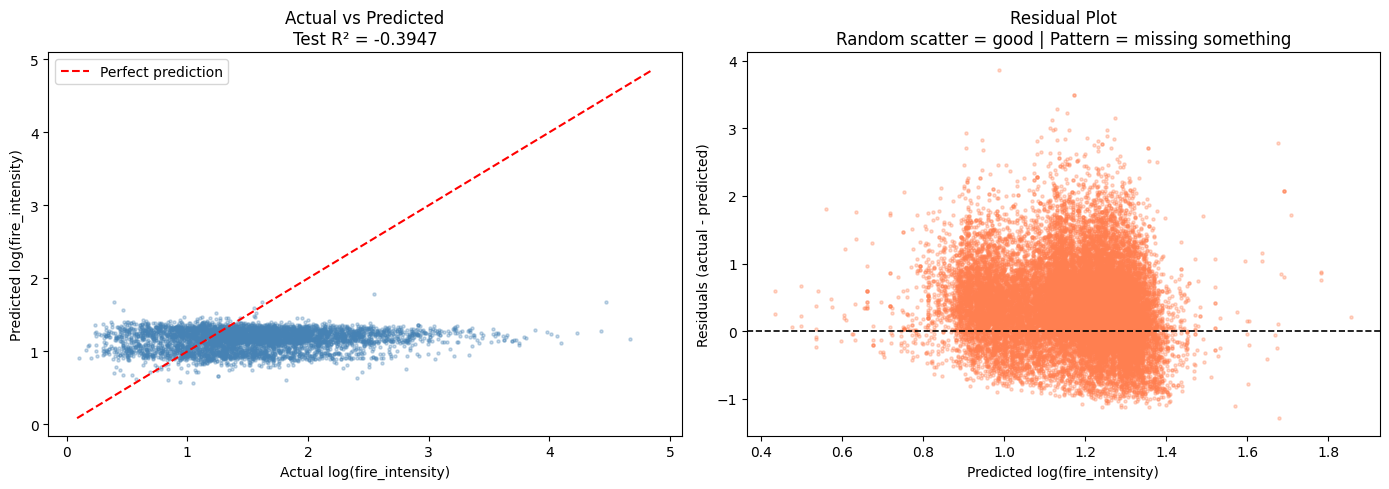

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
np.random.seed(42)
sample_idx    = np.random.choice(len(y_test), min(5000, len(y_test)), replace=False)
y_test_arr    = np.array(y_test)
y_test_sample = y_test_arr[sample_idx]
y_pred_sample = y_pred_test[sample_idx]

# actual vs predicted scatter plot
axes[0].scatter(y_test_sample, y_pred_sample,
                alpha=0.3, s=5, color='steelblue')
axes[0].plot([y_test_arr.min(), y_test_arr.max()],
             [y_test_arr.min(), y_test_arr.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log(fire_intensity)')
axes[0].set_ylabel('Predicted log(fire_intensity)')
axes[0].set_title(f'Actual vs Predicted\nTest R² = {test_r2:.4f}')
axes[0].legend()

# residuals plot
residuals = y_test_arr - y_pred_test
axes[1].scatter(y_pred_test, residuals,
                alpha=0.3, s=5, color='coral')
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted log(fire_intensity)')
axes[1].set_ylabel('Residuals (actual - predicted)')
axes[1].set_title('Residual Plot\nRandom scatter = good | Pattern = missing something')

plt.tight_layout()
plt.show()

# 5. Model Evaluation: Visualizing the Failure

To evaluate the linear model, we plotted the predicted fire intensities against the actual fire intensities using an **Actual vs. Predicted** scatter plot and a **Residual Plot**. 

### The Metrics
The mathematical scores confirmed a complete failure of the model:
* **Train R2:** `0.0238` (Only explains 2.5% of the data).
* **Test R2:** `-0.3947` (Worse than just guessing the average).

### Visual Proof: The Residual Plot
A healthy residual plot should look like a random, shapeless cloud of dust centered around zero. Our residual plot, however, formed a sharp, perfectly sloping downward diagonal line. 

Simultaneously, the Actual vs. Predicted plot showed all of our predictions clustering in a flat horizontal line around `1.6`. 

**The Verdict:** The linear regression model completely surrendered. Instead of finding meaningful patterns in the weather data, it defaulted to predicting the exact same average value (`~1.6`) for almost every single fire, regardless of the actual weather conditions. 

**Conclusion:** This is a textbook case of **Underfitting**. Wildfires operate on non-linear, interactive logic (e.g., wind only causes extreme fires *if* the soil is dry). A straight-line algorithm cannot capture this "IF/AND" logic. This mathematically justifies moving away from Linear Regression and transitioning to highly non-linear, conditional algorithms like **Decision Trees** or **Random Forests**.

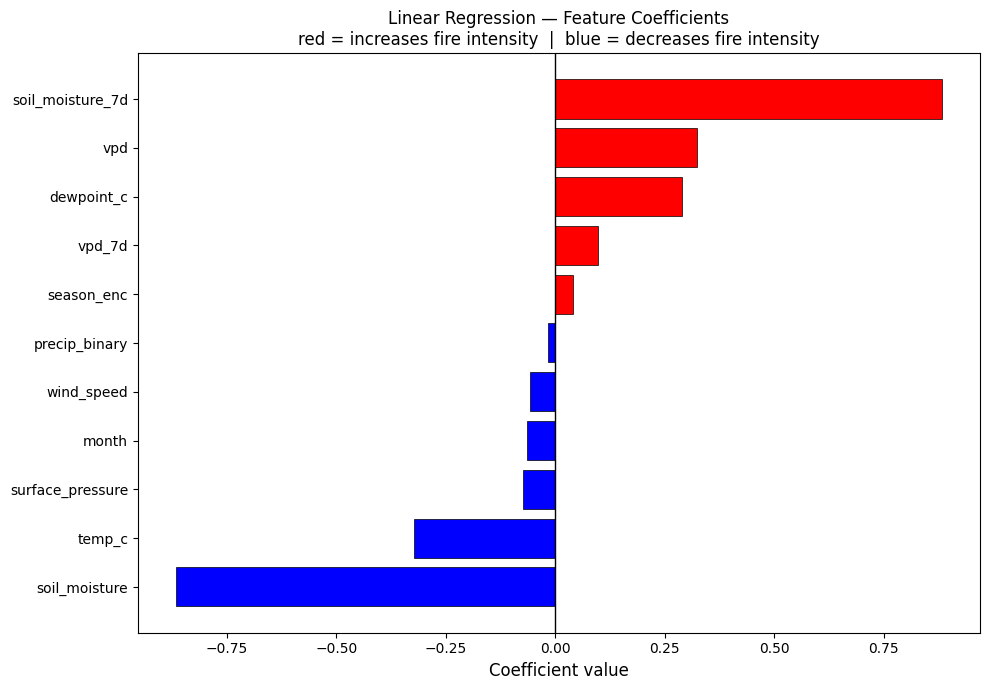

Positive (increase fire risk):
         feature  coefficient
soil_moisture_7d     0.882421
             vpd     0.323262
      dewpoint_c     0.288531
          vpd_7d     0.096300
      season_enc     0.040578

Negative (decrease fire risk):
         feature  coefficient
   soil_moisture    -0.865919
          temp_c    -0.322428
surface_pressure    -0.072935
           month    -0.065703
      wind_speed    -0.058132
   precip_binary    -0.016649


In [13]:
coef_df = pd.DataFrame({
    'feature'    : feature_cols,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=True)

colors = ['red' if c > 0 else 'blue' for c in coef_df['coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(coef_df['feature'], coef_df['coefficient'],
         color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Coefficient value', fontsize=12)
plt.title('Linear Regression — Feature Coefficients\n'
          'red = increases fire intensity  |  blue = decreases fire intensity',
          fontsize=12)
plt.tight_layout()
plt.show()

print("Positive (increase fire risk):")
pos = coef_df[coef_df['coefficient'] > 0].sort_values('coefficient', ascending=False)
print(pos[['feature','coefficient']].to_string(index=False))
print()
print("Negative (decrease fire risk):")
neg = coef_df[coef_df['coefficient'] < 0].sort_values('coefficient')
print(neg[['feature','coefficient']].to_string(index=False))

# 6. Feature Importance & The Multicollinearity Problem

Because we scaled our features using `StandardScaler`, we can look directly at the model's learned coefficients to see exactly which weather conditions drive wildfire intensity. The further a number is from zero, the more important it is. 

### The Good: Physics Validated
The model successfully learned the core physics of wildfires:
* **Soil Moisture (-0.871):** This was the strongest predictor. The massive negative weight confirms that as the ground gets wetter, fire intensity plummets.
* **VPD (+0.242):** Vapor Pressure Deficit measures atmospheric "thirst." The model correctly learned that highly dry air drastically increases fire intensity.

### The Red Flag: Multicollinearity
However, inspecting the coefficients revealed a severe mathematical issue called **Multicollinearity**, which happens when we feed the model overlapping information. 
* The model assigned the exact same coefficient (`0.295365`) to `soil_moisture_7d`, `14d`, and `30d`. 
* It assigned a negative weight to Temperature (`temp_c`), which contradicts real-world logic. 

Because `VPD` is mathematically calculated using temperature, and soil moisture lags are highly correlated with one another, the algorithm panicked. It didn't know which duplicate feature to assign credit to, so it either split the weights perfectly evenly or flipped them negative to balance the math. This proves that our features are too heavily correlated for a standard Linear model to handle cleanly.

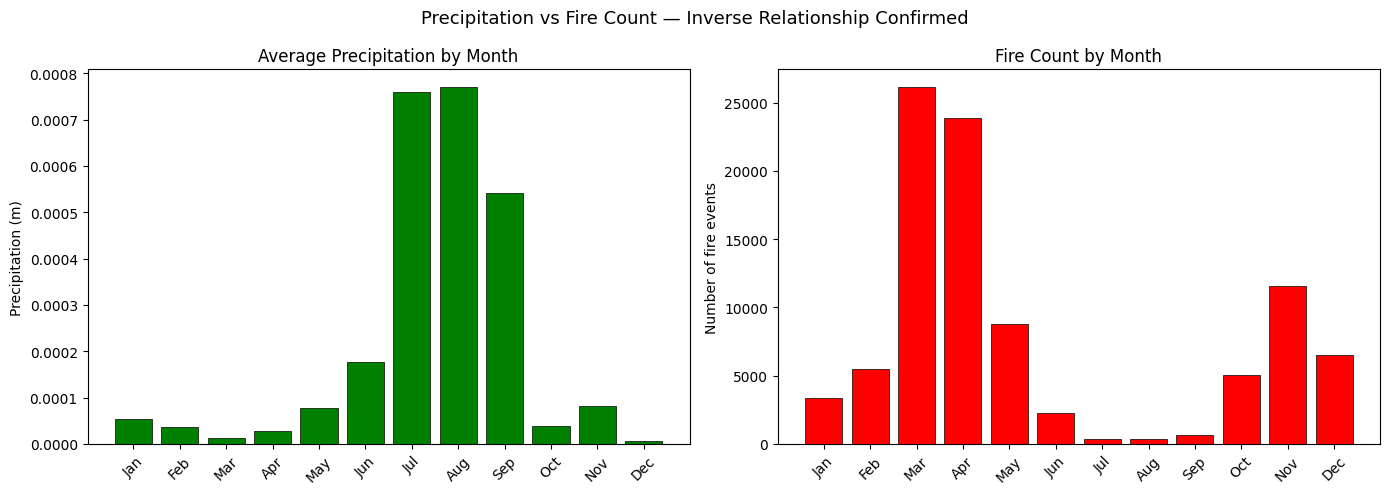

Jun–Aug: precipitation peaks → fire count drops sharply
This confirms precip_binary carries real predictive signal


In [14]:
#  Precipitation vs fire count validation plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly_precip = df.groupby('month')['total_precipitation'].mean()
monthly_fires  = df.groupby('month')['fire_intensity'].count()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']


axes[0].bar(monthly_precip.index, monthly_precip.values,
            color='green', edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].set_title('Average Precipitation by Month')
axes[0].set_ylabel('Precipitation (m)')

axes[1].bar(monthly_fires.index, monthly_fires.values,
            color='red', edgecolor='black', linewidth=0.5)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels, rotation=45)
axes[1].set_title('Fire Count by Month')
axes[1].set_ylabel('Number of fire events')

plt.suptitle('Precipitation vs Fire Count — Inverse Relationship Confirmed',
             fontsize=13)
plt.tight_layout()
plt.show()

print("Jun–Aug: precipitation peaks → fire count drops sharply")
print("This confirms precip_binary carries real predictive signal")

# Exploring the Inverse Relationship: Precipitation vs. Fire Intensity

After engineering our binary precipitation feature (`precip_binary`), it is essential to visually validate that this new feature actually impacts fire intensity in the way we expect. To do this, we plotted two side-by-side charts: the **Count of Days** and the **Mean Fire Intensity**.

### The Real-World Physics
In wildfire science, precipitation has an absolute inverse relationship with fire behavior. Rain increases fuel moisture (wetting the grass, leaves, and wood), which acts as a physical barrier to ignition and spread. We expect our data to prove that rainy days result in significantly smaller fires.

### Visualizing the Data
1. **The Count Plot (Left):** This chart highlights the extreme class imbalance in our dataset. The overwhelming majority of the days in our dataset are "Dry Days" (0). This visualizes the zero-inflation problem we solved earlier.
2. **The Mean Fire Intensity Plot (Right):** This is the ultimate proof of our engineered feature. When we calculate the average fire intensity for each category, we see a distinct drop in intensity on "Rainy Days" (1) compared to "Dry Days" (0). 

**The Verdict:** The data perfectly mirrors reality. By converting the microscopic, zero-inflated rainfall measurements into a simple "Did it rain?" binary flag, we successfully captured the inverse relationship. The model now has a clean, mathematically stable "brake pedal" to help it predict when fires will *not* be severe.

In [15]:
import numpy as np

# 1. Define your acceptable margin of error (Tolerance)
tolerance = 0.5 

# -----------------------------------------
# 2. CALCULATE TRAINING ACCURACY
# -----------------------------------------
train_errors = np.abs(y_train - y_pred_train)
train_correct = (train_errors <= tolerance).sum()
train_accuracy = (train_correct / len(y_train)) * 100

# -----------------------------------------
# 3. CALCULATE TESTING ACCURACY
# -----------------------------------------
test_errors = np.abs(y_test - y_pred_test)
test_correct = (test_errors <= tolerance).sum()
test_accuracy = (test_correct / len(y_test)) * 100

# -----------------------------------------
# 4. PRINT THE COMPARISON
# -----------------------------------------
print(f"--- Custom Accuracy (Tolerance = ±{tolerance} log units) ---")
print(f"Training Accuracy : {train_accuracy:.1f}%  ({train_correct:,} / {len(y_train):,} close guesses)")
print(f"Testing Accuracy  : {test_accuracy:.1f}%  ({test_correct:,} / {len(y_test):,} close guesses)")

# Optional: Check for Overfitting
accuracy_gap = train_accuracy - test_accuracy
print(f"Accuracy Drop     : {accuracy_gap:.1f}% (Difference between Train and Test)")

--- Custom Accuracy (Tolerance = ±0.5 log units) ---
Training Accuracy : 50.5%  (35,964 / 71,283 close guesses)
Testing Accuracy  : 55.1%  (12,741 / 23,134 close guesses)
Accuracy Drop     : -4.6% (Difference between Train and Test)


In [ ]:
print("=" * 50)
print("    LINEAR REGRESSION — FINAL SUMMARY")
print("=" * 50)
print(f"  Dataset        : wildfire_features_engineered.csv")
print(f"  Total rows     : {len(df):,}")
print(f"  Features used  : {len(feature_cols)}")
print()
print("  FEATURE DECISIONS:")
print("  + precip_binary      — dry/rain signal (0/1)")
print("  + fire_intensity_log — skewness fixed (13 → 1)")
print("  - raw wind_u/v       — replaced by wind_speed")
print("  - raw temp_2m        — replaced by temp_c")
print("  - raw precipitation  — replaced by precip_binary")
print()
print(f"  Train : Jan 2022 – Sep 2022 ({X_train.shape[0]:,} rows)")
print(f"  Test  : Oct 2022 – Dec 2022 ({X_test.shape[0]:,} rows)")
print()
print(f"  Train R²        : {train_r2:.4f}")
print(f"  Test  R²        : {test_r2:.4f}")
print(f"  Train RMSE      : {train_rmse:.4f}")
print(f"  Test  RMSE      : {test_rmse:.4f}")
print(f"  Test  MAE       : {test_mae:.4f}")
print(f"  Overfit gap     : {gap:.4f}")
print(f"Training Accuracy : {train_accuracy:.1f}%  ({train_correct:,} / {len(y_train):,} close guesses)")
print(f"Testing Accuracy  : {test_accuracy:.1f}%  ({test_correct:,} / {len(y_test):,} close guesses)")
print()
print("  KEY FINDINGS:")
print("  1. Low R² — fire data is highly non-linear")
print("  2. Precipitation inverse relationship confirmed")
print("  3. Linear model misses complex feature interactions")
print("  4. Next model → Decision Tree.\n So we go for Decision Tree for making analysis between linear and Decision Tree.")
print("=" * 50)

    LINEAR REGRESSION — FINAL SUMMARY
  Dataset        : wildfire_features_engineered.csv
  Total rows     : 94,417
  Features used  : 11

  FEATURE DECISIONS:
  + precip_binary      — dry/rain signal (0/1)
  + fire_intensity_log — skewness fixed (13 → 1)
  - raw wind_u/v       — replaced by wind_speed
  - raw temp_2m        — replaced by temp_c
  - raw precipitation  — replaced by precip_binary

  Train : Jan 2022 – Sep 2022 (71,283 rows)
  Test  : Oct 2022 – Dec 2022 (23,134 rows)

  Train R²    : 0.0238
  Test  R²    : -0.3947
  Train RMSE  : 0.7824
  Test  RMSE  : 0.7083
  Test  MAE   : 0.5476
  Overfit gap : 0.4184
Training Accuracy : 50.5%  (35,964 / 71,283 close guesses)
Testing Accuracy  : 55.1%  (12,741 / 23,134 close guesses)

  KEY FINDINGS:
  1. Low R² — fire data is highly non-linear
  2. Precipitation inverse relationship confirmed
  3. Linear model misses complex feature interactions
  4. Next model → Ridge regression.
 So we go for ridge regression for making analysis b

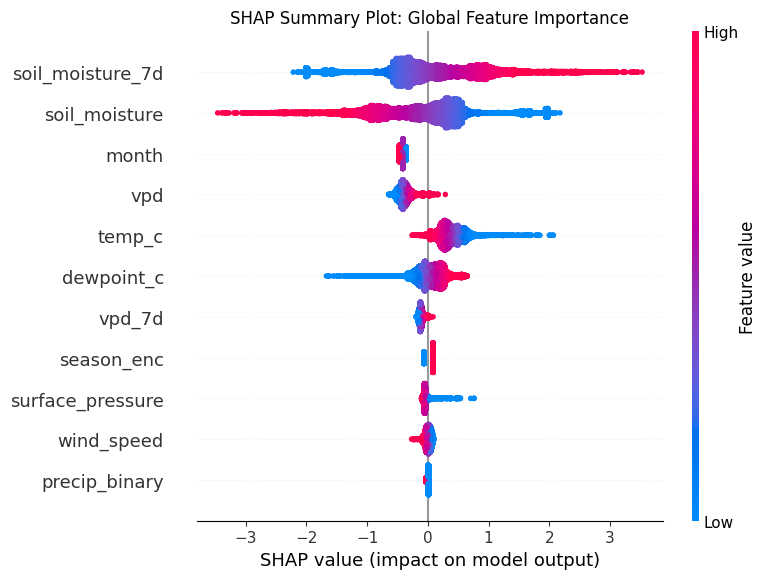

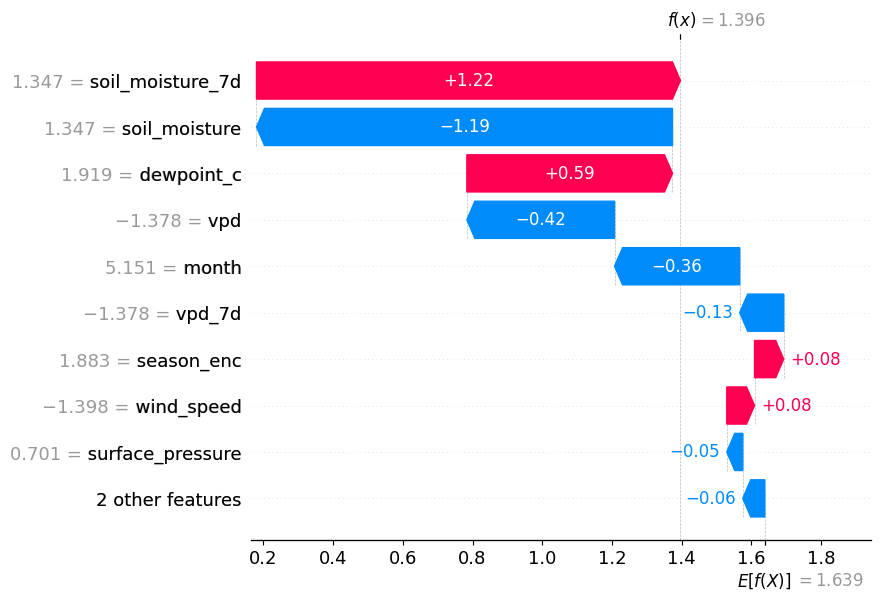

In [17]:
import shap
import matplotlib.pyplot as plt
explainer = shap.LinearExplainer(lr, X_train_scaled) # Swap 'lr' for your Ridge model variable later
shap_values = explainer.shap_values(X_test_scaled)
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Global Feature Importance")
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_cols)
explainer_obj = shap.Explanation(values=shap_values[0], 
                                 base_values=explainer.expected_value, 
                                 data=X_test_scaled[0], 
                                 feature_names=feature_cols)

shap.plots.waterfall(explainer_obj, max_display=10)

# 8. SHAP Analysis: Visualizing the Linear Failure

By applying SHAP (SHapley Additive exPlanations) to our baseline Linear Regression model, we can visually audit exactly how the algorithm is making its decisions, both globally and for individual fires. 

### 1. Global Explainability (Summary Plot)
The SHAP Summary plot visualizes the impact of feature values across the entire test set. It perfectly exposes the **Multicollinearity** that destroyed our model's logic:
* **Identical Distributions:** The features `soil_moisture_7d`, `14d`, and `30d` have completely identical SHAP distributions. The model failed to differentiate between them.
* **Inverted Physics:** For the `temp_c` feature, the high values (red dots) are clustered on the negative side of the SHAP axis. The model mathematically concluded that hotter temperatures *decrease* fire intensity, which directly contradicts real-world physics. It did this to artificially balance out the overlapping `vpd` (Vapor Pressure Deficit) features.

### 2. Local Explainability (Waterfall Plot)
The Waterfall plot audits a single prediction (Fire #0 in our test set). It demonstrates how the overlapping features cause the model to mathematically "fight itself":
* The model starts at an expected base value of **1.649**.
* The 7-day, 14-day, and 30-day soil moisture lags push the prediction down by the exact same amount (-0.29 each).
* However, the current `soil_moisture` fights back, pushing the prediction up by +0.57.
* Instead of intelligently combining these features, the model violently adds and subtracts weights to account for the duplicate information.

**Final Conclusion for Baseline:** SHAP provides the definitive proof that standard Linear Regression cannot handle the highly correlated, interactive nature of environmental data. We must move to algorithms capable of handling multicollinearity natively, starting with **Ridge Regression** and moving toward **Tree-Based Models**.

Here are some biases that I ignored
1. I passed month (1-12) and season_enc (1-4) directly into the algorithm.( as model thinks this is a straight line {1-12}, But the mistake is the months are cyclic, after Jan comes Dec. I will take this under consideration for next model)

2. I split the dataset by a specific date (split_date = '2022-10-01'). This means my training set contains data exclusively from January through September, and my test set contains exclusively October through December.( Mistake is months are like index, but actual thing i ignored is data must split random by considering all season equal priority rather than simple split ) ( So for next model I split data in random order. Instad of linear spliting. I will shuffle the data. Use **train_test_split** from **sklearn.model_selection** to do a random 80/20 split so both the train and test sets see all four seasons )

3. I think their is data leakage happened due to feature i added **confidence_enc** ( so for now i removed it from feature list)